In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
INPUT_DIR = "dataset"
OUTPUT_DIR = "dataset_wav"

os.makedirs(OUTPUT_DIR, exist_ok=True)

supported_ext = [".mp3", ".m4a", ".aac", ".wav", ".ogg"]

for label in os.listdir(INPUT_DIR):
    class_in = os.path.join(INPUT_DIR, label)
    class_out = os.path.join(OUTPUT_DIR, label)

    if not os.path.isdir(class_in):
        continue

    os.makedirs(class_out, exist_ok=True)

    print(f"\nProcessing class: {label}")

    for file in os.listdir(class_in):
        ext = os.path.splitext(file)[1].lower()

        if ext not in supported_ext:
            continue

        in_path = os.path.join(class_in, file)

        try:
            audio, sr = librosa.load(in_path, sr=16000, mono=True)

            out_file = os.path.splitext(file)[0] + ".wav"
            out_path = os.path.join(class_out, out_file)

            sf.write(out_path, audio, sr)

        except Exception as e:
            print(f"Error {file}: {e}")


Processing class: ayam


c:\Users\SINTIAWATI\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\SINTIAWATI\AppData\Local\Temp\ipykernel_11252\2285211894.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(in_path, sr=16000, mono=True)
c:\Users\SINTIAWATI\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
C:\Users\SINTIAWATI\AppData\Local\Temp\ipykernel_11252\2285211894.py:28: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(in_path, sr=16000, mono=True)
c:\Users\SINTIAWATI\AppData\Loca


Processing class: bebek

Processing class: cicak

Processing class: gajah

Processing class: harimau

Processing class: kelinci

Processing class: kucing

Processing class: panda

Processing class: sapi

Processing class: zebra


In [3]:
DATASET_PATH = "dataset_wav"

X = []
y = []

def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, sr=16000, mono=True)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)

    return mfcc

for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)

        try:
            mfcc = extract_mfcc(file_path)
            X.append(mfcc)
            y.append(label)
        except:
            print("skip:", file_path)

In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

X = np.array(X)

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [7]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=300,
    random_state=42,
    verbose=True
)

model.fit(X_train, y_train)

Iteration 1, loss = 2.44408464
Iteration 2, loss = 2.30663490
Iteration 3, loss = 2.18839264
Iteration 4, loss = 2.09054708
Iteration 5, loss = 1.99332559
Iteration 6, loss = 1.90620863
Iteration 7, loss = 1.82107759
Iteration 8, loss = 1.73942792
Iteration 9, loss = 1.65886629
Iteration 10, loss = 1.57945061
Iteration 11, loss = 1.50012934
Iteration 12, loss = 1.42198205
Iteration 13, loss = 1.34546459
Iteration 14, loss = 1.27008438
Iteration 15, loss = 1.19640946
Iteration 16, loss = 1.12513268
Iteration 17, loss = 1.05612254
Iteration 18, loss = 0.99023581
Iteration 19, loss = 0.92734623
Iteration 20, loss = 0.86682034
Iteration 21, loss = 0.80867732
Iteration 22, loss = 0.75378716
Iteration 23, loss = 0.70199239
Iteration 24, loss = 0.65245116
Iteration 25, loss = 0.60633457
Iteration 26, loss = 0.56364310
Iteration 27, loss = 0.52261192
Iteration 28, loss = 0.48458570
Iteration 29, loss = 0.45016947
Iteration 30, loss = 0.41695291
Iteration 31, loss = 0.38601503
Iteration 32, los

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,300
,shuffle,True
,random_state,42


In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.975
              precision    recall  f1-score   support

        ayam       1.00      0.88      0.93         8
       bebek       1.00      1.00      1.00         8
       cicak       1.00      1.00      1.00         8
       gajah       1.00      1.00      1.00         8
     harimau       0.89      1.00      0.94         8
     kelinci       1.00      1.00      1.00         8
      kucing       1.00      1.00      1.00         8
       panda       1.00      1.00      1.00         8
        sapi       0.89      1.00      0.94         8
       zebra       1.00      0.88      0.93         8

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



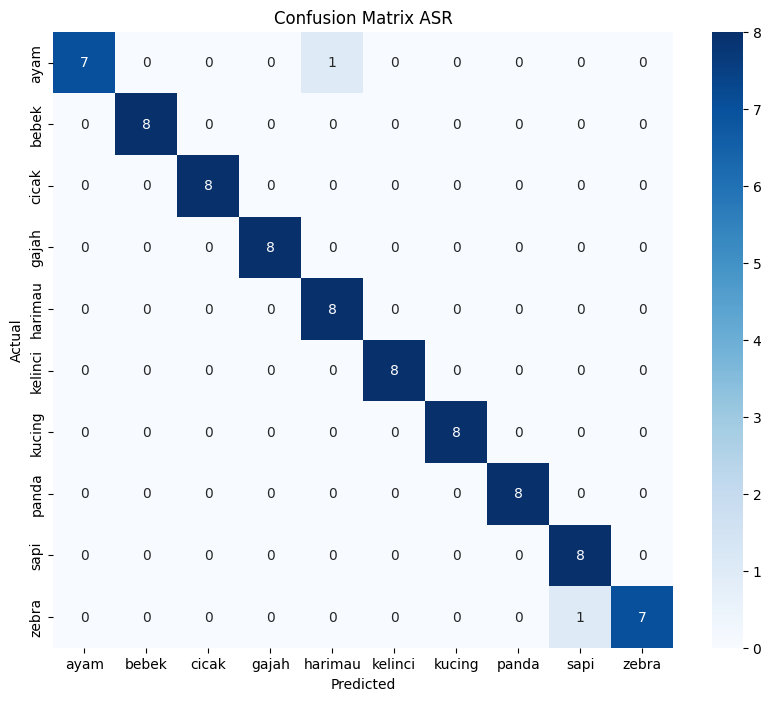

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")

plt.title("Confusion Matrix ASR")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
os.makedirs("models", exist_ok=True)

joblib.dump(model, "models/mlp_model.pkl")
joblib.dump(scaler, "models/mlp_scaler.pkl")
joblib.dump(le, "models/mlp_label_encoder.pkl")

['models/mlp_label_encoder.pkl']